In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

In [61]:
#load data
df = pd.read_csv("cox-violent-parsed_filt.csv")

In [62]:
#basic information
print("Shape of dataset:", df.shape)
print("\nColumns in dataset:\n", df.columns.tolist())

# check missing values
print("\nMissing values per column (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

# general info about column types
df.info()

# basic statistics for numerical columns
df.describe()


Shape of dataset: (18316, 40)

Columns in dataset:
 ['id', 'name', 'first', 'last', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'violent_recid', 'is_violent_recid', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'priors_count.1', 'event']

Missing values per column (top 10):
violent_recid         18316
vr_offense_date       16977
vr_charge_degree      16977
vr_charge_desc        16977
r_jail_in             11957
r_days_from_arrest    11957
r_charge_desc         10039
r_charge_degree        9899
r_offense_date         9899
id                     7315
dtype: in

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,event
count,11001.00000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,17019.000000,17449.000000,18316.000000,6359.000000,0.0,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000
mean,5501.00000,34.019273,0.076873,4.997052,0.098439,0.124263,3.913191,4.302485,57.694596,0.414774,19.961629,NaN,0.073105,4.997052,4.022822,3.913191,0.044715
std,3175.85949,11.667811,0.464272,2.937569,0.517639,0.524537,5.299864,81.159881,317.994694,0.576449,74.139695,NaN,0.260317,2.937569,2.614189,5.299864,0.206683
min,1.00000,18.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,-597.000000,0.000000,-1.000000,-1.000000,NaN,0.000000,-1.000000,-1.000000,0.000000,0.000000
25%,2751.00000,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,2.000000,2.000000,0.000000,0.000000
50%,5501.00000,31.000000,0.000000,5.000000,0.000000,0.000000,2.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,5.000000,4.000000,2.000000,0.000000
75%,8251.00000,41.000000,0.000000,8.000000,0.000000,0.000000,5.000000,0.000000,2.000000,1.000000,1.000000,NaN,0.000000,8.000000,6.000000,5.000000,0.000000
max,11001.00000,96.000000,20.000000,10.000000,13.000000,17.000000,43.000000,1057.000000,9485.000000,1.000000,993.000000,NaN,1.000000,10.000000,10.000000,43.000000,1.000000


In [63]:
#Preprocessing

#negative values in days_b_screening_arrest were treated as missing ()
df["days_b_screening_arrest"] = df["days_b_screening_arrest"].clip(lower=0)

#tagert is is_recid
df["target"] = df["is_recid"]

leak_cols = [
    "is_recid", 
    "is_violent_recid", 
    "violent_recid",
    "r_charge_desc",
    "r_charge_degree",
    "r_offense_date",
    "r_jail_in",
    "r_days_from_arrest",
    "priors_count.1"
]

df = df.drop(columns=[c for c in leak_cols if c in df.columns])


Race Distribution:
 race
African-American    0.534560
Caucasian           0.332278
Hispanic            0.079220
Other               0.046953
Asian               0.003876
Native American     0.003112
Name: proportion, dtype: float64


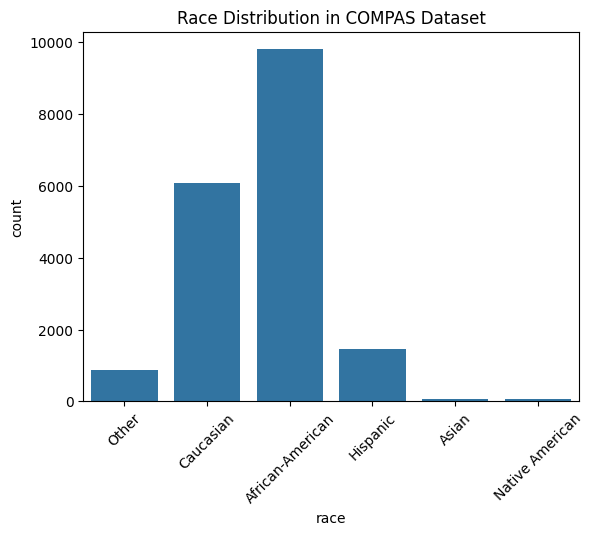

In [64]:
# race distribution
race_dist = df["race"].value_counts(normalize=True)
print("Race Distribution:\n", race_dist)

sns.countplot(x="race", data=df)
plt.xticks(rotation=45)
plt.title("Race Distribution in COMPAS Dataset")
plt.show()

data is racially imbalanced: africa-american represent 53% and caucasian 33%, while other groups are substantially smaller.

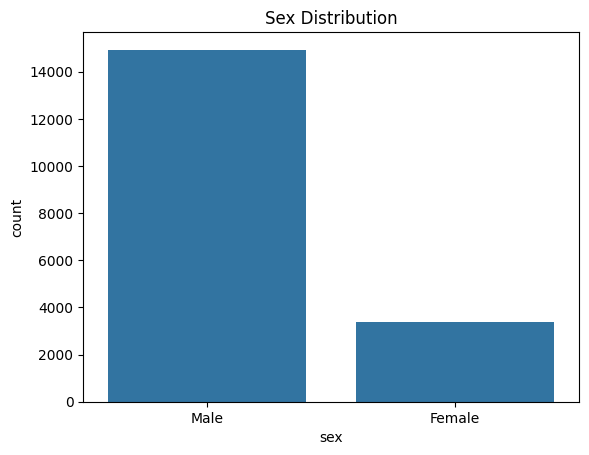

In [65]:
#sex distribution

sns.countplot(x="sex", data=df)
plt.title("Sex Distribution")
plt.show()


strong imbalance: males being vastly overrepresented

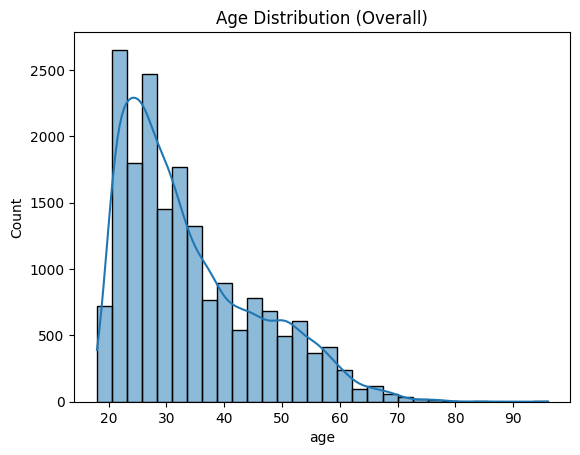

In [66]:
# age distributioon
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution (Overall)")
plt.show()


most individuals between 20 and 40 years old, indicating that age is likely to play a significant role in any recidivism prediction model 

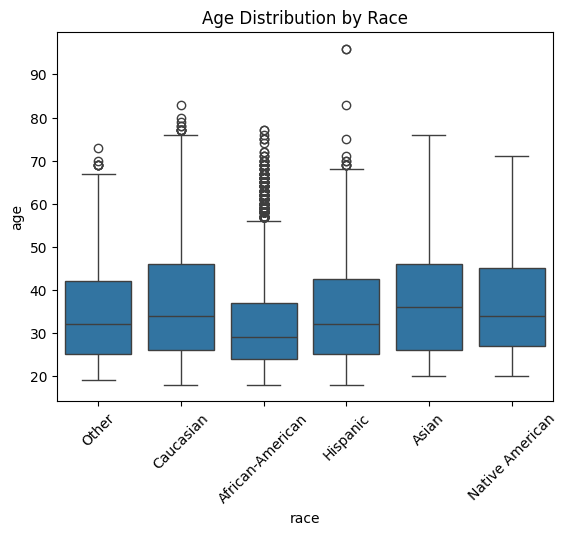

In [67]:
# compare age across races
sns.boxplot(x="race", y="age", data=df)
plt.xticks(rotation=45)
plt.title("Age Distribution by Race")
plt.show()

median ages look similar for all the groups but for African American there are a lot of outliers which will potentially affect the prediction

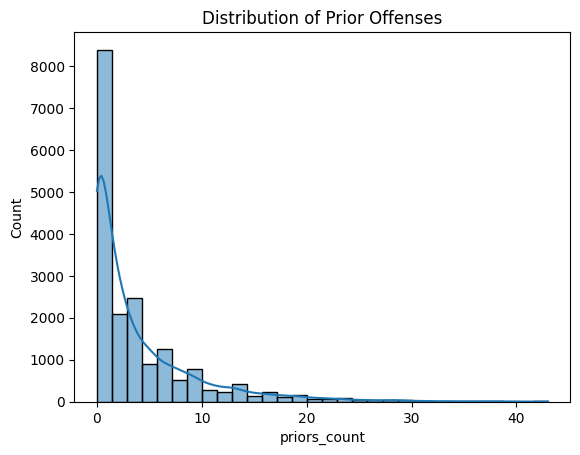

In [68]:
# priors count distribution
sns.histplot(df["priors_count"], bins=30, kde=True)
plt.title("Distribution of Prior Offenses")
plt.show()


a small subset of individuals with very high prior counts may disproportionately influence model predictions

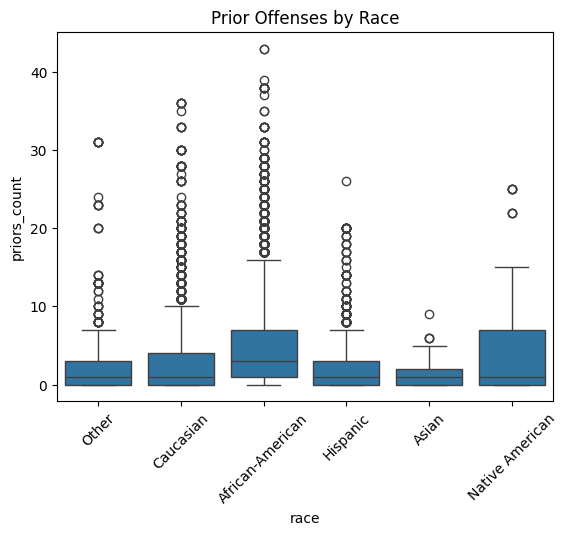

Average priors by race:
race
African-American    4.913390
Asian               1.394366
Caucasian           2.943805
Hispanic            2.289456
Native American     5.438596
Other               2.232558
Name: priors_count, dtype: float64


In [69]:
#Priors by race
sns.boxplot(x="race", y="priors_count", data=df)
plt.xticks(rotation=45)
plt.title("Prior Offenses by Race")
plt.show()

print("Average priors by race:")
print(df.groupby("race")["priors_count"].mean())


In [70]:
#juvenile offenses by race--
print("Average juvenile offenses by race:")
print(df.groupby("race")[["juv_fel_count", 
                           "juv_misd_count", 
                           "juv_other_count"]].mean())


Average juvenile offenses by race:
                  juv_fel_count  juv_misd_count  juv_other_count
race                                                            
African-American       0.114493        0.145644         0.156164
Asian                  0.000000        0.014085         0.014085
Caucasian              0.028590        0.041735         0.097765
Hispanic               0.047553        0.036527         0.065472
Native American        0.245614        0.017544         0.175439
Other                  0.034884        0.079070         0.053488


Recidivism rate by race:
 race
African-American    0.480952
Asian               0.169014
Caucasian           0.356556
Hispanic            0.274983
Native American     0.333333
Other               0.334884
Name: target, dtype: float64


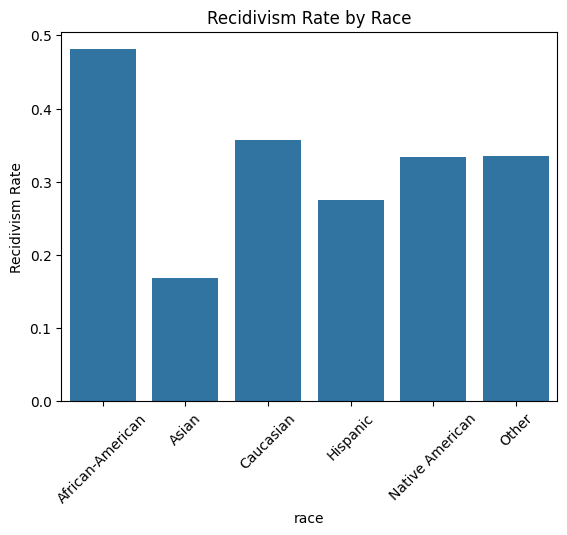

In [71]:
# recidivsim by race
recid_by_race = df.groupby("race")["target"].mean()
print("Recidivism rate by race:\n", recid_by_race)

sns.barplot(x=recid_by_race.index, y=recid_by_race.values)
plt.xticks(rotation=45)
plt.ylabel("Recidivism Rate")
plt.title("Recidivism Rate by Race")
plt.show()


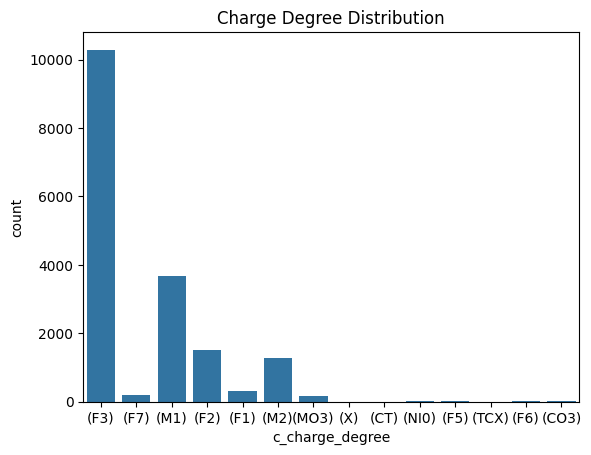

Recidivism rate by charge degree:
c_charge_degree
(CO3)    1.000000
(CT)     0.000000
(F1)     0.278523
(F2)     0.445775
(F3)     0.516029
(F5)     0.000000
(F6)     0.000000
(F7)     0.391304
(M1)     0.421896
(M2)     0.457521
(MO3)    0.512987
(NI0)    0.733333
(TCX)    0.000000
(X)      0.000000
Name: target, dtype: float64


In [72]:
#charge degree distribution
sns.countplot(x="c_charge_degree", data=df)
plt.title("Charge Degree Distribution")
plt.show()

print("Recidivism rate by charge degree:")
print(df.groupby("c_charge_degree")["target"].mean())


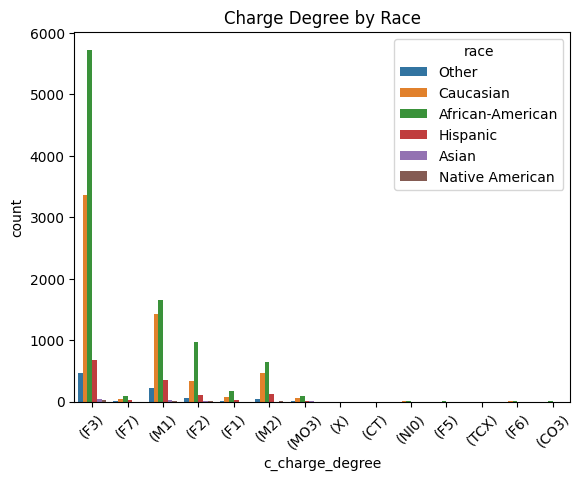

In [73]:
sns.countplot(x="c_charge_degree", hue="race", data=df)
plt.title("Charge Degree by Race")
plt.xticks(rotation=45)
plt.show()


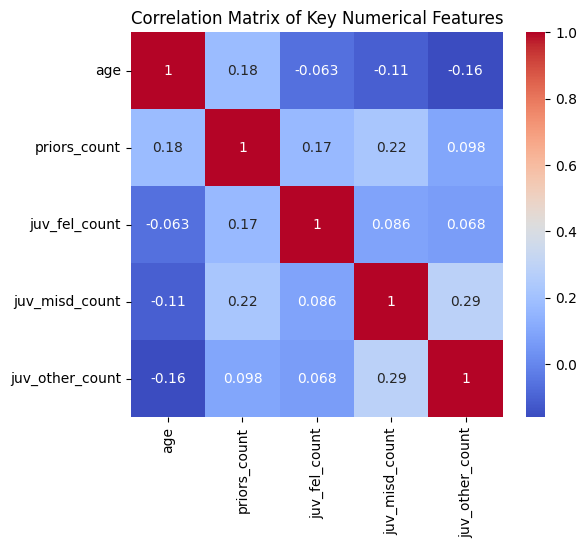

In [74]:
#correlation matrix
num_cols = ["age", 
            "priors_count", 
            "juv_fel_count", 
            "juv_misd_count", 
            "juv_other_count"]

corr = df[num_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Key Numerical Features")
plt.show()


low correlation which means different information

correlation matrix shows only weak relationships between age, adult priors, and different types of juvenile offenses.

In [75]:
#check negative values
print("Examples of negative days_b_screening_arrest:")
print(df[df["days_b_screening_arrest"] < 0][["days_b_screening_arrest"]].head())


Examples of negative days_b_screening_arrest:
Empty DataFrame
Columns: [days_b_screening_arrest]
Index: []


In [ ]:
# creating feature set
y = df["target"]

X = df.drop(columns=["target"])

X = X.drop(columns=["id", "name", "first", "last", "dob"], errors="ignore")



In [77]:
# fill missing values with median
num_cols = X.select_dtypes(include=["float64", "int64"]).columns

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())


In [78]:
X = pd.get_dummies(
    X,
    columns=["sex", "race", "c_charge_degree"],
    drop_first=True
)



In [79]:
print("\nColumns AFTER encoding:\n")
print(X.columns.tolist())
X.head()



Columns AFTER encoding:

['age', 'age_cat', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_days_from_compas', 'c_charge_desc', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'event', 'sex_Male', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other', 'c_charge_degree_(CT)', 'c_charge_degree_(F1)', 'c_charge_degree_(F2)', 'c_charge_degree_(F3)', 'c_charge_degree_(F5)', 'c_charge_degree_(F6)', 'c_charge_degree_(F7)', 'c_charge_degree_(M1)', 'c_charge_degree_(M2)', 'c_charge_degree_(MO3)', 'c_charge_degree_(NI0)', 'c_charge_degree_(TCX)', 'c_charge_degree_(X)']


,age,age_cat,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,...,c_charge_degree_(F3),c_charge_degree_(F5),c_charge_degree_(F6),c_charge_degree_(F7),c_charge_degree_(M1),c_charge_degree_(M2),c_charge_degree_(MO3),c_charge_degree_(NI0),c_charge_degree_(TCX),c_charge_degree_(X)
0,69,Greater than 45,0,1,0,0,0,0.0,13/08/2013 6:03,14/08/2013 5:41,...,True,False,False,False,False,False,False,False,False,False
1,69,Greater than 45,0,1,0,0,0,0.0,13/08/2013 6:03,14/08/2013 5:41,...,True,False,False,False,False,False,False,False,False,False
2,31,25 - 45,0,5,0,0,0,0.0,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
3,34,25 - 45,0,3,0,0,0,0.0,26/01/2013 3:45,05/02/2013 5:36,...,True,False,False,False,False,False,False,False,False,False
4,24,Less than 25,0,4,0,1,4,0.0,13/04/2013 4:58,14/04/2013 7:02,...,True,False,False,False,False,False,False,False,False,False
